# Demo tutorial for doing preprocessing of crispr adata 
Note don't use this notebook for larger libraries 

In [1]:
import os, sys
import scanpy as sc
sys.path.insert(0, '/Users/chandrima.modak/CRISPRai-GW/src/preprocessing')
import preprocess_adata as ppr_adata

In [2]:
# Path to cellranger output
path = '/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/gw-CRISPRa/Diff053/cellranger/CRISPRia_Cellanome_lane1/per_sample_outs/D1_392i_Rest/count/sample_filtered_feature_bc_matrix.h5'

In [3]:
# Initializing the adata object
anndata_obj = ppr_adata.Adata_Qc_preprocessing(
    path=path, 
    exp= 'crispr',
    library_id='D1_392i_Rest',
    lane= 'lane1'
)
# Reading the h5 data
anndata_obj.get_assay()

AnnData object with n_obs × n_vars = 24768 × 22108
    obs: 'library_id', 'lane_id'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

In [4]:
#Check prefix in guide names 
anndata_obj.adata.var_names[anndata_obj.adata.var['feature_types'] != 'Gene Expression']

# if there is any prefix to the guides use 
# anndata_obj.clean_prefix(anndata_obj.adata, prefix="")

Index(['ACAT1_A_CRISPRi_1', 'ACAT1_A_CRISPRi_2', 'ACAT1_A_CRISPRi_3',
       'ACTB_A_CRISPRi_1', 'ACTB_A_CRISPRi_2', 'ACTB_A_CRISPRi_3',
       'ADORA2A_A_CRISPRi_1', 'ADORA2A_A_CRISPRi_2', 'ADORA2A_A_CRISPRi_3',
       'AKT1_A_CRISPRi_1',
       ...
       'NDUFA4L2_A_CRISPRa_3', 'PGF_A_CRISPRa_3', 'POU5F1B_A_CRISPRa_3',
       'CRLF2_A_CRISPRa_3', 'BOLA1_A_CRISPRa_3', 'ANKRD33B_A_CRISPRa_3',
       'MYH3_A_CRISPRa_3', 'SPAG4_A_CRISPRa_3', 'BCL6_A_CRISPRa_3',
       'NO-TARGET_A_CRISPRa_3'],
      dtype='object', length=3979)

In [5]:
#splitting assay
anndata_obj.gex_a, anndata_obj.crispr_a = anndata_obj.split_assay(anndata_obj.adata)

In [6]:
# removing dead cells or potential doublets with high mitochondrial
mito_pct = 20
anndata_obj._basic_qc_gex(mt_pct= mito_pct, filter_cells = True)
print(f"Pre filtering cell counts: {anndata_obj.pre_filter_cells}")
print(f"Post filtering cell counts: {anndata_obj.post_filter_cells}")

Pre filtering cell counts: 24768
Post filtering cell counts: 24757


In [7]:
# Computing the guide assay umi counts 
anndata_obj.get_sgrna_qc_metrics()

AnnData object with n_obs × n_vars = 24768 × 3979
    obs: 'library_id', 'lane_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'sgrna_id', 'perturbed_gene_name', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'n_cells', 'mean_counts', 'total_counts', 'nonz_means'

In [8]:
# Saving the raw counts before log+1 normalization 
# normalization can be target sum of 10k, here it is done median count depth 
anndata_obj.gex_a.layers['counts'] = anndata_obj.gex_a.X.copy()
sc.pp.normalize_total(anndata_obj.gex_a)
sc.pp.log1p(anndata_obj.gex_a)

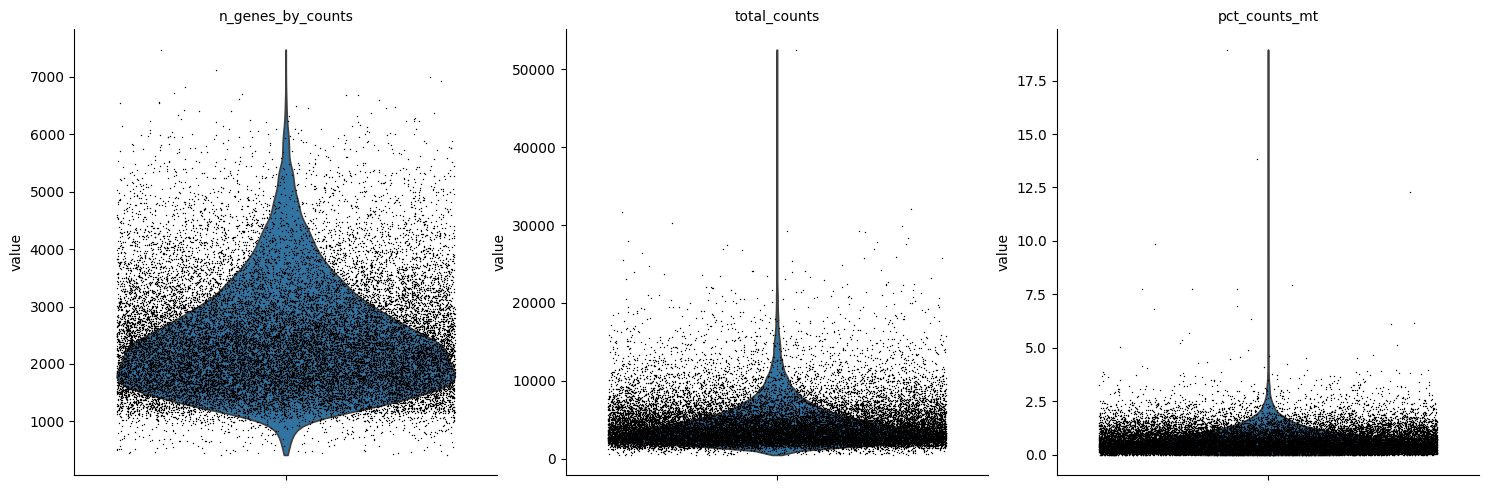

In [9]:
sc.pl.violin(
    anndata_obj.gex_a,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

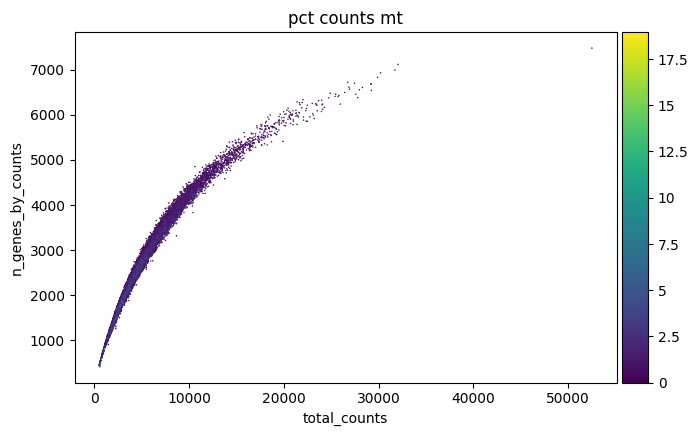

In [10]:
sc.pl.scatter(anndata_obj.gex_a, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

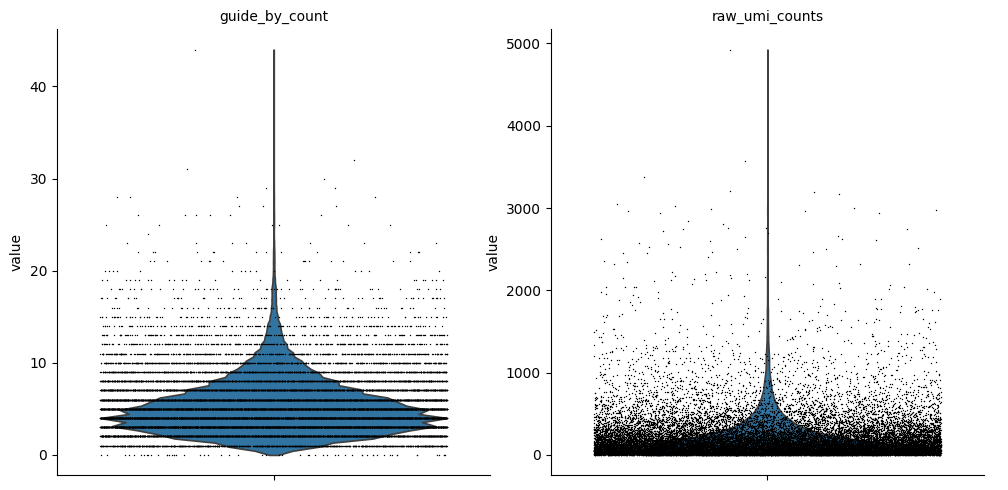

In [11]:
anndata_obj.crispr_a.obs = anndata_obj.crispr_a.obs.rename(columns={"n_genes_by_counts": "guide_by_count", 
                                                                    "total_counts" : "raw_umi_counts"})
sc.pl.violin(
    anndata_obj.crispr_a,
    ["guide_by_count", "raw_umi_counts"],
    jitter=0.4,
    multi_panel=True,
)

In [ ]:
anndata_obj.gex_a.write_h5ad()
anndata_obj.crispr_a.write_h5ad()

### Alternatively the above steps can be done using the process_cellranger_h5 function

In [12]:

gex_a, crispr_a, pre_count, post_count = ppr_adata.process_cellranger_h5(
    path=path,
    exp= 'crispr',
    sample_name='D1_392i_Rest',
    lane= 'lane1', 
    prefix = None, 
    mt_pct = 20, 
    filter_cells = True
        )

In [13]:
pre_count

24768